# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 1: Image Understanding and Compression with PCA

---

In [ ]:
# Install required libraries (run this cell in Google Colab)
#pip install Pillow numpy matplotlib -q

---
## Exercise 1: RGB Image Processing
---

Mounted at /content/drive
Array shape: (183, 276, 3)  | dtype: uint8


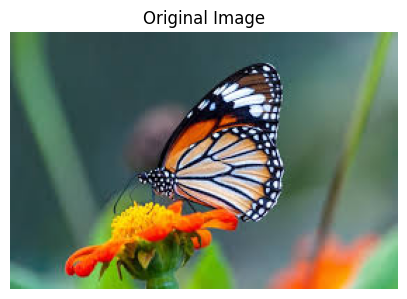

In [5]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Mount drive
drive.mount('/content/drive')

# Path inside Drive
image_path = "/content/drive/MyDrive/butterfly.jpeg"

# Open image
img_pil = Image.open(image_path).convert("RGB")

# Convert to array
img_array = np.array(img_pil)

print(f"Array shape: {img_array.shape}  | dtype: {img_array.dtype}")

# Display image
plt.figure(figsize=(5,5))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

 Top-left shape: (100, 100, 3)


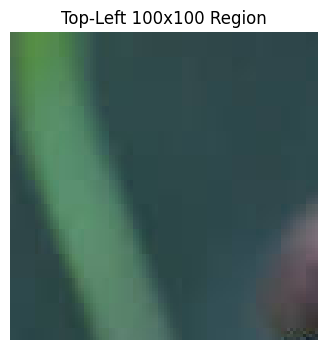

In [24]:

try:
    img_array
except NameError:
    raise ValueError(" img_array not found. Please run Task 1 first.")

# Extract top-left 100x100 region
top_left = img_array[:100, :100]

print(f" Top-left shape: {top_left.shape}")

# Display cropped image
plt.figure(figsize=(4,4))
plt.imshow(top_left)
plt.title("Top-Left 100x100 Region")
plt.axis("off")
plt.show()

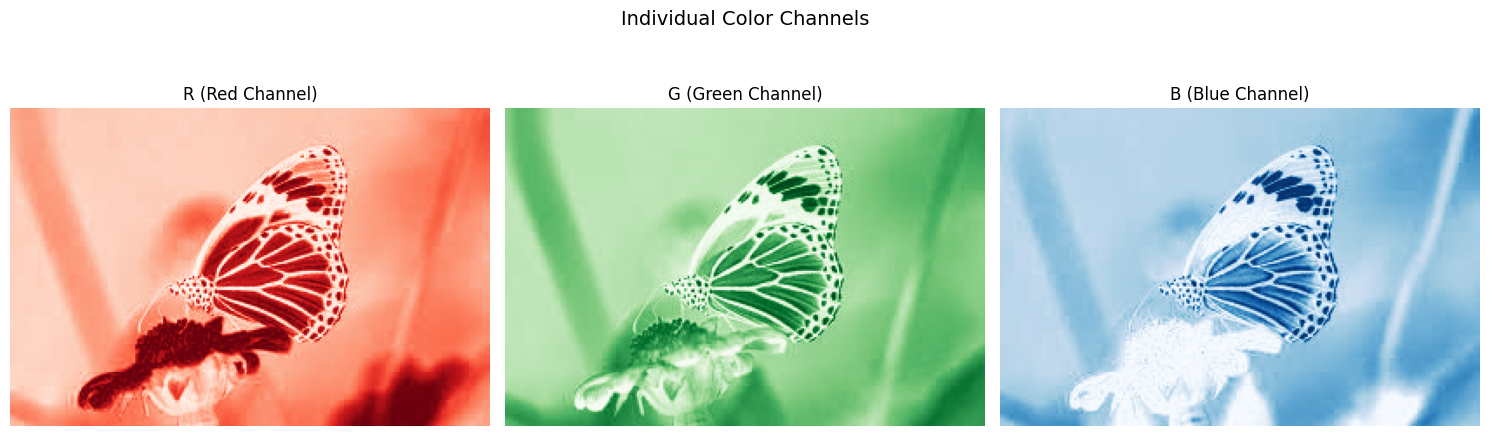

Note: Matplotlib applies colour maps; Pillow would show these as grayscale.


In [9]:
# ── Task 3: Separate and Display R, G, B Channels ────────────────────────────
# Each channel is a 2-D array of intensity values (0-255)
R = img_array[:, :, 0]   # Red channel
G = img_array[:, :, 1]   # Green channel
B = img_array[:, :, 2]   # Blue channel

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R, cmap="Reds")
axes[0].set_title("R (Red Channel)")
axes[0].axis("off")

axes[1].imshow(G, cmap="Greens")
axes[1].set_title("G (Green Channel)")
axes[1].axis("off")

axes[2].imshow(B, cmap="Blues")
axes[2].set_title("B (Blue Channel)")
axes[2].axis("off")

plt.suptitle("Individual Color Channels", fontsize=14)
plt.tight_layout()
plt.show()

print("Note: Matplotlib applies colour maps; Pillow would show these as grayscale.")

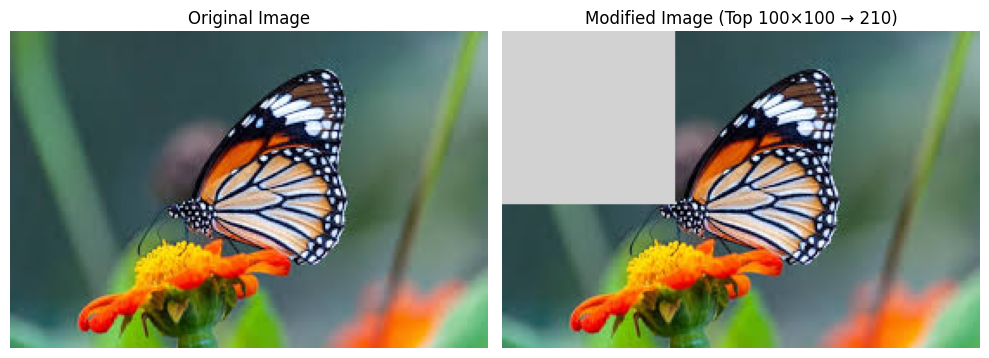

In [10]:
# ── Task 4: Set Top-Left 100×100 Region to 210 ───────────────────────────────
# Work on a copy so the original array remains intact
img_modified = img_array.copy()
img_modified[:100, :100, :] = 210   # 210 ≈ light-gray in all channels

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_array)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(img_modified)
axes[1].set_title("Modified Image (Top 100×100 → 210)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## Exercise 2: Grayscale Image Processing
---

In [11]:
# ── Load a Grayscale Image ────────────────────────────────────────────────────
# Using the classic "cameraman" test image from scikit-image (no extra install needed via URL)
gray_url = "https://upload.wikimedia.org/wikipedia/commons/b/b8/Lena_Webb_with_Playmate_Issue.jpg"

# We will convert the already-loaded Lena image to grayscale for Exercise 2
gray_pil = img_pil.convert("L")          # 'L' = 8-bit grayscale
gray_array = np.array(gray_pil)          # shape: (H, W)
print(f"Grayscale array shape: {gray_array.shape}  |  dtype: {gray_array.dtype}")

Grayscale array shape: (183, 276)  |  dtype: uint8


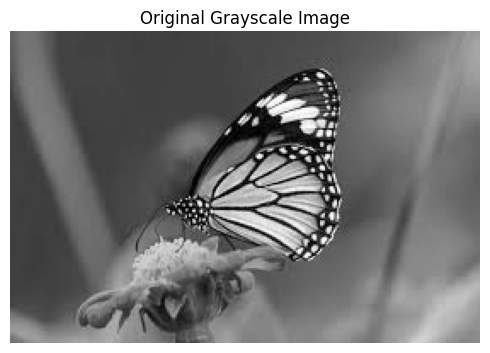

In [12]:
# ── Task 1: Load and Display Grayscale Image ──────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(gray_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.tight_layout()
plt.show()

Middle section shape: (150, 150)


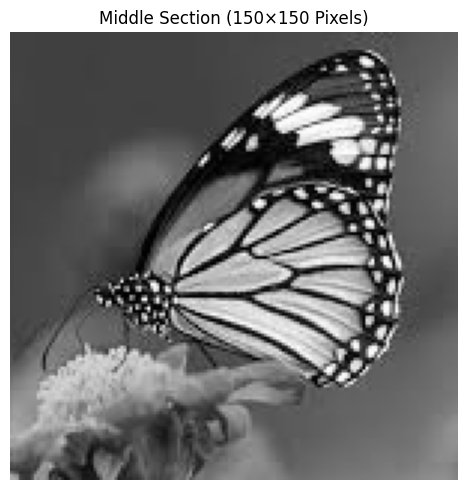

In [13]:
# ── Task 2: Extract Middle 150×150 Section ────────────────────────────────────
h, w = gray_array.shape
center_row, center_col = h // 2, w // 2

# Slice 75 pixels in each direction from the centre
middle_section = gray_array[
    center_row - 75 : center_row + 75,
    center_col - 75 : center_col + 75
]
print(f"Middle section shape: {middle_section.shape}")

plt.figure(figsize=(5, 5))
plt.imshow(middle_section, cmap="gray")
plt.title("Middle Section (150×150 Pixels)")
plt.axis("off")
plt.tight_layout()
plt.show()

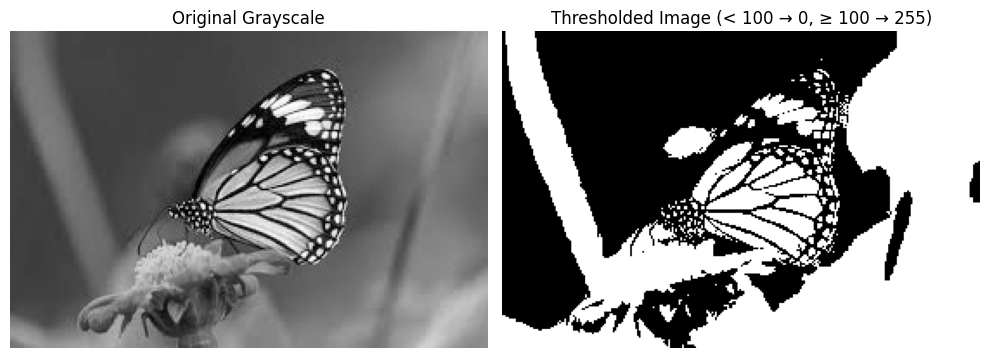

In [14]:
# ── Task 3: Threshold the Grayscale Image ─────────────────────────────────────
# Values < 100  → 0 (black)
# Values >= 100 → 255 (white)
binary_array = np.where(gray_array < 100, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_array, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(binary_array, cmap="gray")
axes[1].set_title("Thresholded Image (< 100 → 0, ≥ 100 → 255)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

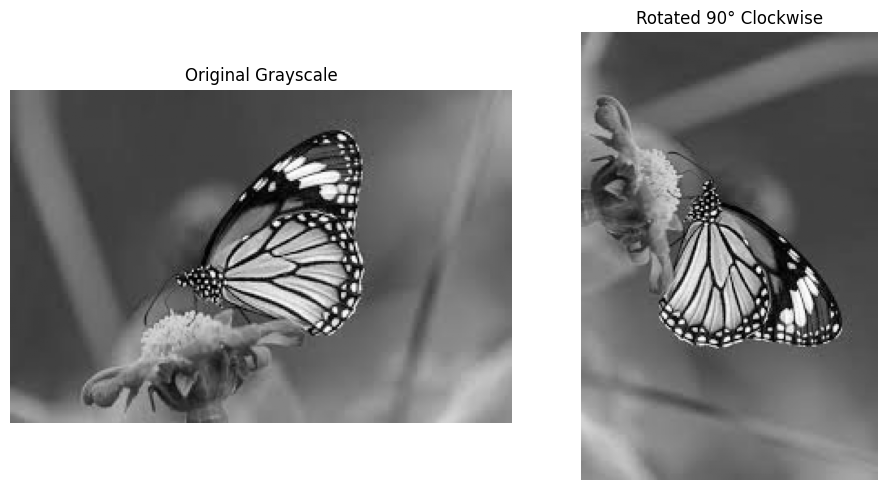

In [15]:
# ── Task 4: Rotate 90 Degrees Clockwise ───────────────────────────────────────
# Pillow's rotate() uses counter-clockwise convention, so we pass -90 (or expand=True keeps full image)
rotated_pil  = gray_pil.rotate(-90, expand=True)
rotated_array = np.array(rotated_pil)

# Alternative using NumPy:
# rotated_array = np.rot90(gray_array, k=-1)   # k=-1 → 90° clockwise

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_array, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(rotated_array, cmap="gray")
axes[1].set_title("Rotated 90° Clockwise")
axes[1].axis("off")

plt.tight_layout()
plt.show()

RGB-from-gray array shape: (183, 276, 3)


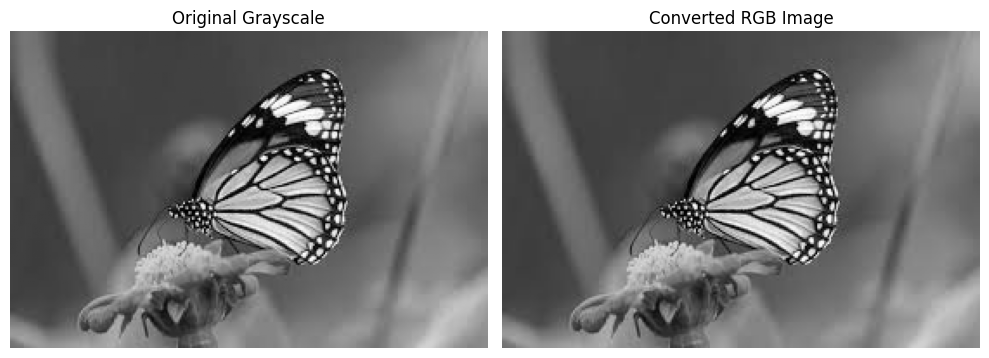

Note: The converted RGB image looks identical to grayscale because R=G=B at every pixel.


In [16]:
# ── Task 5: Convert Grayscale to RGB ─────────────────────────────────────────
# Stack the same grayscale channel 3 times along a new third axis → (H, W, 3)
rgb_from_gray = np.stack([gray_array, gray_array, gray_array], axis=-1)
print(f"RGB-from-gray array shape: {rgb_from_gray.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_array, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(rgb_from_gray)
axes[1].set_title("Converted RGB Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()
print("Note: The converted RGB image looks identical to grayscale because R=G=B at every pixel.")

---
## Exercise 3: Image Compression & Decompression using PCA (from Scratch)
---

We build **PCA entirely from scratch** using NumPy — no `sklearn`.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load, Convert to Grayscale, and Prepare (Centre) the Data
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request, io

# Reuse the grayscale image loaded earlier
X = gray_array.astype(np.float64)   # shape: (H, W)
H, W = X.shape
print(f"Image shape: {H} rows × {W} cols")

# ── Standardise: subtract the mean of each COLUMN (feature) ──────────────────
col_mean = X.mean(axis=0)            # mean of each column  →  shape (W,)
X_centered = X - col_mean            # broadcast across rows
print(f"Column means range: [{col_mean.min():.2f}, {col_mean.max():.2f}]")
print(f"Centered data mean (should ≈ 0): {X_centered.mean():.6f}")

Image shape: 183 rows × 276 cols
Column means range: [75.78, 141.48]
Centered data mean (should ≈ 0): -0.000000


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Covariance Matrix
# ══════════════════════════════════════════════════════════════════════════════
# Covariance matrix has shape (W, W) — pixels treated as features
# C = (1 / (H-1)) * X_centered.T @ X_centered
C = np.cov(X_centered, rowvar=False)   # rowvar=False → columns are variables
print(f"Covariance matrix shape: {C.shape}")

Covariance matrix shape: (276, 276)


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Eigen Decomposition & Sort Eigenvalues (Descending)
# ══════════════════════════════════════════════════════════════════════════════
eigenvalues, eigenvectors = np.linalg.eigh(C)   # eigh: symmetric / Hermitian matrix

# np.linalg.eigh returns in ASCENDING order → flip to get descending
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]              # each COLUMN is an eigenvector

print(f"Top-5 eigenvalues: {eigenvalues[:5].round(2)}")
print(f"Eigenvector matrix shape: {eigenvectors.shape}")

Top-5 eigenvalues: [96759.97 64247.47 43869.97 28093.82 25340.71]
Eigenvector matrix shape: (276, 276)


80% variance explained by 15 components
90% variance explained by 25 components
95% variance explained by 36 components
99% variance explained by 65 components


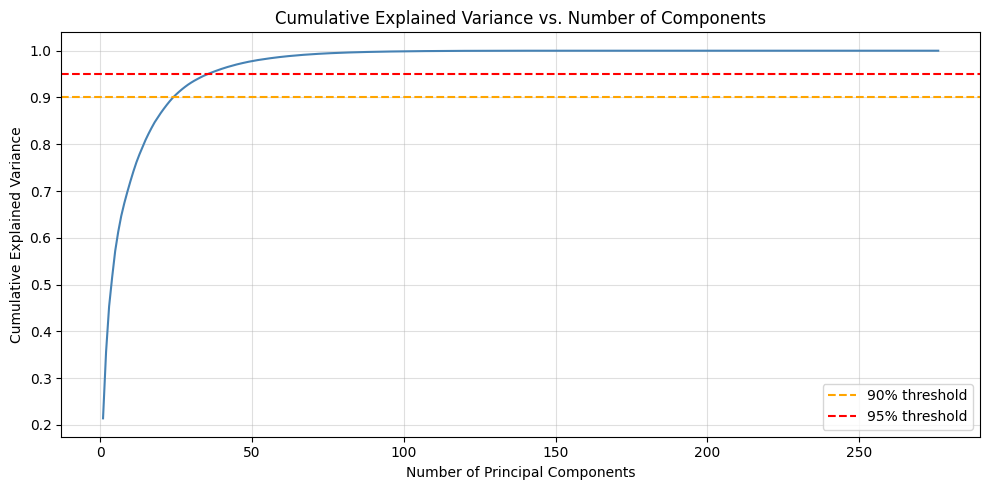

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Cumulative Explained Variance Plot
# ══════════════════════════════════════════════════════════════════════════════
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance      = np.cumsum(explained_variance_ratio)

# Find how many components explain 90%, 95%, 99%
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {k} components")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=1.5, color="steelblue")
plt.axhline(0.90, color="orange", linestyle="--", label="90% threshold")
plt.axhline(0.95, color="red",    linestyle="--", label="95% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — PCA Compression & Reconstruction Helper Function
# ══════════════════════════════════════════════════════════════════════════════
def pca_reconstruct(X_centered, eigenvectors, k, col_mean):
    """
    Compress and then reconstruct an image using the top-k principal components.

    Parameters
    ----------
    X_centered  : 2D array (H, W) — mean-subtracted image
    eigenvectors: 2D array (W, W) — columns are eigenvectors (sorted descending)
    k           : int — number of principal components to keep
    col_mean    : 1D array (W,)   — column means used to centre the data

    Returns
    -------
    reconstructed : 2D uint8 array (H, W) — pixel values clipped to [0, 255]
    compression_ratio : float
    """
    # Select top-k eigenvectors  →  shape (W, k)
    W_k = eigenvectors[:, :k]

    # Project data onto lower-dimensional subspace  →  shape (H, k)
    scores = X_centered @ W_k

    # Reconstruct back in original dimension  →  shape (H, W)
    X_reconstructed = scores @ W_k.T + col_mean

    # Clip to valid pixel range and convert to uint8
    X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)

    # Compression ratio: original pixels vs. stored numbers
    H, W = X_centered.shape
    original_size    = H * W
    compressed_size  = H * k + W * k   # scores + eigenvectors
    compression_ratio = original_size / compressed_size

    return X_reconstructed, compression_ratio

print("Helper function defined.")

Helper function defined.


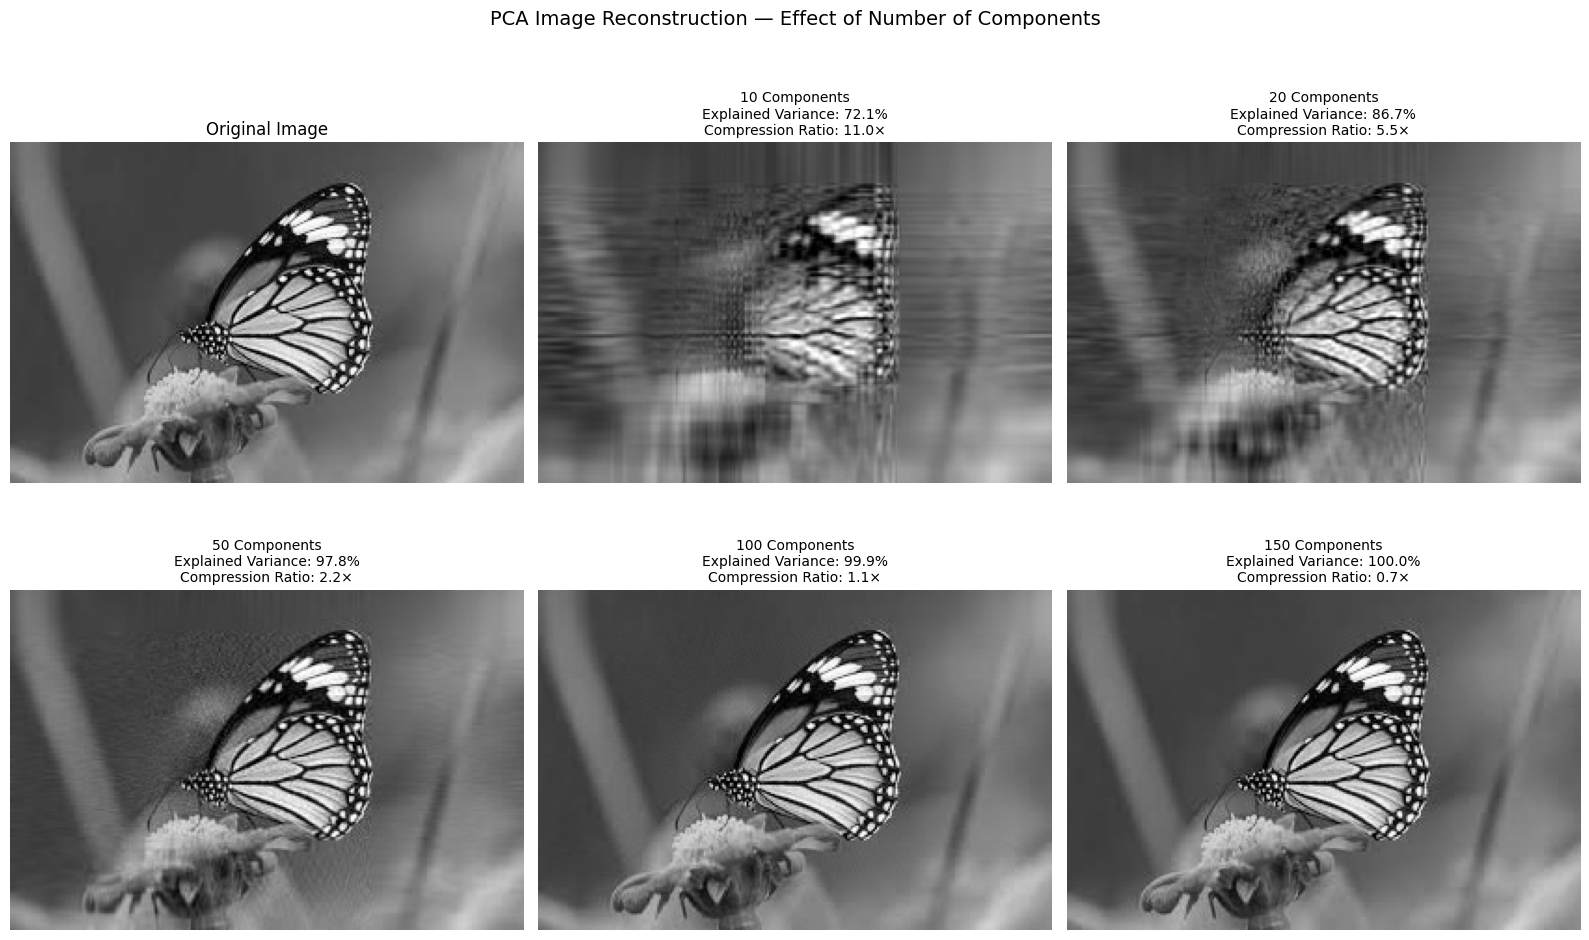

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Experiment: Four Different k Values
# ══════════════════════════════════════════════════════════════════════════════
k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Plot original
axes[0].imshow(gray_array, cmap="gray")
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

for i, k in enumerate(k_values):
    reconstructed, cr = pca_reconstruct(X_centered, eigenvectors, k, col_mean)
    explained = cumulative_variance[k - 1] * 100

    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(
        f"{k} Components\n"
        f"Explained Variance: {explained:.1f}%\n"
        f"Compression Ratio: {cr:.1f}×",
        fontsize=10
    )
    axes[i + 1].axis("off")

plt.suptitle("PCA Image Reconstruction — Effect of Number of Components", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Quantitative Evaluation Table
# ══════════════════════════════════════════════════════════════════════════════
print(f"{'k':>6}  {'Expl. Var (%)':>15}  {'Compression Ratio':>20}  {'MSE':>10}")
print("-" * 60)

for k in k_values:
    reconstructed, cr = pca_reconstruct(X_centered, eigenvectors, k, col_mean)
    explained = cumulative_variance[k - 1] * 100
    mse = np.mean((gray_array.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)
    print(f"{k:>6}  {explained:>14.2f}%  {cr:>19.2f}×  {mse:>10.2f}")

     k    Expl. Var (%)     Compression Ratio         MSE
------------------------------------------------------------
    10           72.07%                11.00×      453.46
    20           86.68%                 5.50×      214.45
    50           97.77%                 2.20×       36.10
   100           99.87%                 1.10×        2.44
   150          100.00%                 0.73×        0.50


---
## Summary

| Exercise | Key Concepts Covered |
|---|---|
| **1** | PIL image loading, NumPy array indexing, channel separation with `cmap`, pixel modification |
| **2** | Grayscale loading, centre crop via slicing, thresholding with `np.where`, rotation, grayscale→RGB stacking |
| **3** | Data centring, covariance matrix, `np.linalg.eigh`, cumulative variance plot, PCA projection & reconstruction |

### Key Observations on PCA Compression
- **10 components** — very blurry; only coarse structure visible (~low explained variance).
- **50 components** — recognisable image; good compression ratio.
- **100 components** — close to original; suitable for most applications.
- **150 components** — near-perfect reconstruction with high explained variance.

Increasing `k` improves quality but **reduces the compression benefit**.
The optimal `k` balances acceptable image quality against storage savings.

---
*6CS012 — Worksheet 1 | Artificial Intelligence and Machine Learning*